In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv('Titanic-Dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.shape

(891, 12)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [8]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

### dropping columns
- PassengerId is just an identifier. It doesn't describe the passenger. The model may mistakenly try to learn patterns from it, which is meaningless.

- Most Cabin values are missing (over 70%).

In [9]:
X=df.drop(columns='Survived')
y=df['Survived']

### seperating the numerical and categorical columns

In [10]:
num_cols=X.select_dtypes(include='number').columns
cat_cols=X.select_dtypes(include='object').columns
num_cols , cat_cols


(Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object'),
 Index(['Sex', 'Embarked'], dtype='object'))

In [11]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [12]:
SimpleImputer(strategy='median')

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [13]:
SimpleImputer(strategy='most_frequent')

,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [14]:
Xtrain.isnull().sum()  #missing value

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [15]:
Xtrain["Age"].skew()

0.3310017370749743

A general guideline is:

    - Between -0.5 and 0.5 → Approximately symmetric 
    - Between -1 and -0.5 or 0.5 and 1 → Moderately skewed
    - Less than -1 or greater than 1 → Highly skewed

<Axes: >

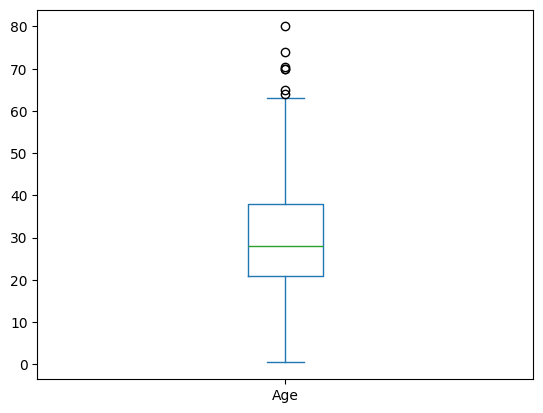

In [16]:
Xtrain["Age"].plot(kind="box")

- **StandardScaler** → Good default for many models (like Logistic Regression, SVM, KNN). 

   - It centers the data around 0 with unit variance.
- **MinMaxScaler** → Scales values to a fixed range (usually 0–1). 

   - Useful for algorithms like Neural Networks or when you specifically need bounded values.

### Rule to remember

- **OrdinalEncoder** → Use when categories have a real order, e.g., Low < Medium < High, or Poor < Average < Good < Excellent.
- **OneHotEncoder** → Use for nominal categories like Gender, City, Color, Embarked.

### Pipeline Creation

In [17]:
Num_Pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

In [18]:
Cat_Pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

### Column Transformer

In [19]:
Transformer = ColumnTransformer(
    transformers=[
        ('Num_trans', Num_Pipeline, num_cols),
        ('Cat_trans', Cat_Pipeline, cat_cols)
    ]
)

In [20]:
final_pipeline = Pipeline(
    steps=[
        ('preprocessor', Transformer),
        ('model', LogisticRegression())
    ]
)

In [21]:
# model trainig:
final_pipeline.fit(Xtrain, ytrain)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Num_trans', ...), ('Cat_trans', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
#model prediction
y_pred = final_pipeline.predict(Xtest)

In [23]:
accuracy_score(ytest, y_pred)
confusion_matrix(ytest, y_pred)

print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

